# Polarization analysis

In [1]:
%load_ext autoreload
%autoreload 2

In [3]:
import pandas as pd
import numpy as np
from pert2state_model import Perturb2StateModel

import matplotlib.pyplot as plt

## Load target signature

In [83]:
signature_df = pd.read_csv("../../Th1_vs_Th0_DE_results.csv")
signature_df["zscore"] = signature_df["log_fc"] / signature_df["lfcSE"]
y_target = signature_df.set_index("variable")["zscore"]

## Load perturb-seq signatures

In [84]:
X_perturbs = pd.read_parquet("../../X_perturbs_example.parquet")
X_perturbs.shape

(10079, 8481)

In [85]:
common_gs = np.intersect1d(y_target.index, X_perturbs.index)
sample_common_gs = np.random.choice(common_gs, 3000, replace=False)

X_perturbs = X_perturbs.loc[sample_common_gs]
# X_perturbs = X_perturbs[np.random.choice(X_perturbs.columns, 500, replace=False)]
y_target = y_target.loc[sample_common_gs]

## Fit model of target state from perturbations

In [9]:
model = Perturb2StateModel(pca_transform=True, n_splits=1, n_repeats=1)
model.fit(X_perturbs.loc[sample_common_gs[0:3]], y_target.loc[sample_common_gs[0:3]], model_id="test")

In [86]:
model = Perturb2StateModel(pca_transform=True, n_splits=3, n_repeats=1, l1_ratio=np.logspace(-1, 1, 10), alpha=[1])
model.fit(X_perturbs.loc[sample_common_gs], y_target.loc[sample_common_gs], model_id="test")
model.summarize_eval()

,alpha,alpha_se,l1_ratio,l1_ratio_se,train_r2,train_r2_se,train_spearman,train_spearman_se,train_pearson,train_pearson_se,...,test_pearson,test_pearson_se,test_kendall,test_kendall_se,test_spearman_p,test_spearman_p_se,test_pearson_p,test_pearson_p_se,test_kendall_p,test_kendall_p_se
model_id,,,,,,,,,,,,,,,,,,,,,
test,1.0,0.0,0.1,0.0,0.3167,0.0033,0.5667,0.0088,0.57,0.0058,...,0.5467,0.0176,0.3833,0.012,0.0,0.0,0.0,0.0,0.0,0.0


In [123]:
X_perturbs["IL4R"]

KRT18      -0.398721
COL5A2     -0.345974
HOXB5      -0.025949
SLC35B2     0.465068
ACTL6A      0.376849
              ...   
E2F8       -1.043065
RAPGEF2    -1.320321
C11orf21    0.292386
ORAI2      -0.167415
TLR4       -0.073301
Name: IL4R, Length: 3000, dtype: float64

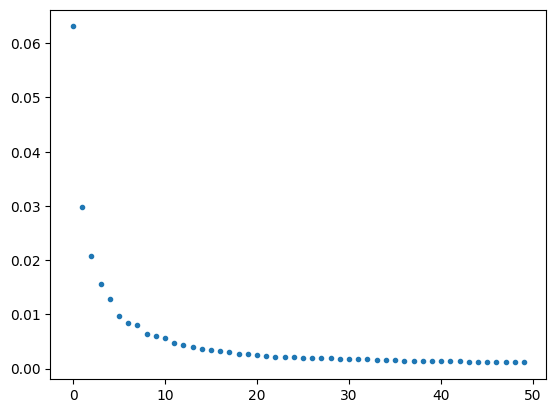

In [87]:
truncSVD = model.pcas[0]
explained_variance_ratio = truncSVD.explained_variance_ratio_
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)
plt.plot(explained_variance_ratio, ".")

Text(0, 0.5, 'PC2')

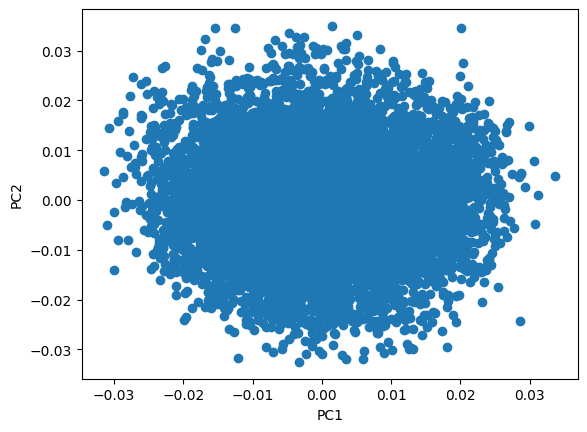

In [92]:
pca_df = pd.DataFrame(truncSVD.components_[0:4, :].T, index=X_perturbs.columns)
plt.scatter(pca_df[0], pca_df[1])
plt.xlabel("PC1")
plt.ylabel("PC2")

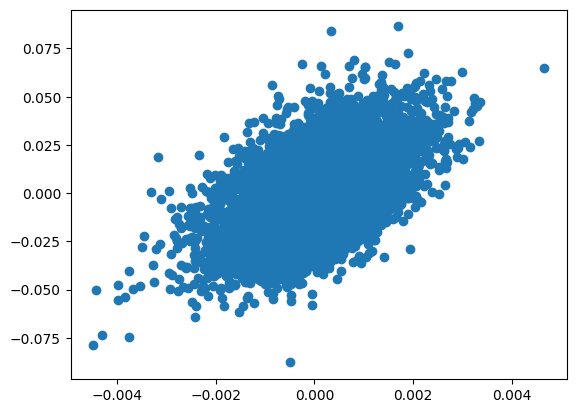

In [114]:
pca_df = pd.DataFrame(truncSVD.components_.T, index=X_perturbs.columns)
coefs_df = model.get_coefs()

pl_df = pd.concat([coefs_df, pca_df], axis=1)
# pl_df.corr()['coef_mean'].sort_values()
plt.scatter(pl_df["coef_mean"], pl_df[23] - pl_df[8] + pl_df[1])

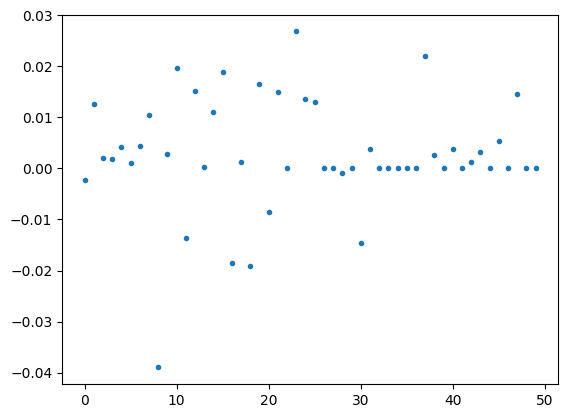

In [107]:
coefs = model.models[0].coef_
plt.plot(coefs, ".")
# plt.scatter(ranks, coefs)
# plt.xlabel('Rank')
# plt.ylabel('Coefficient Value')

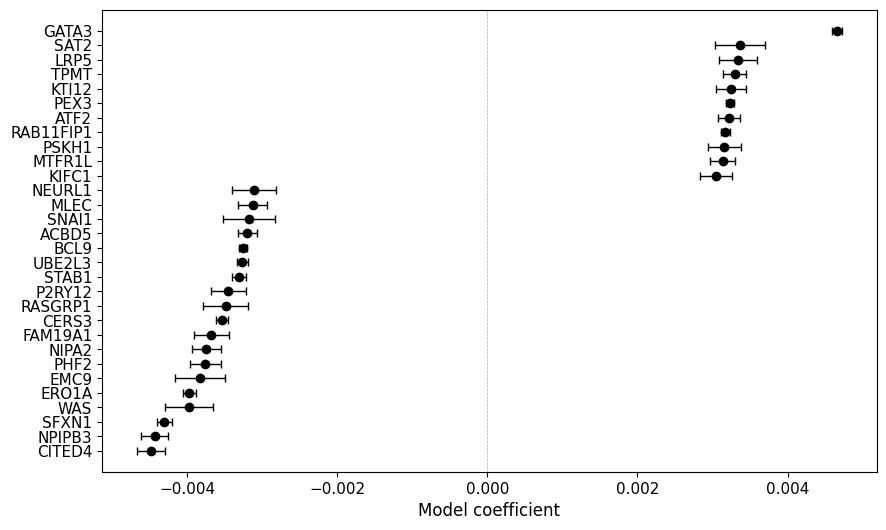

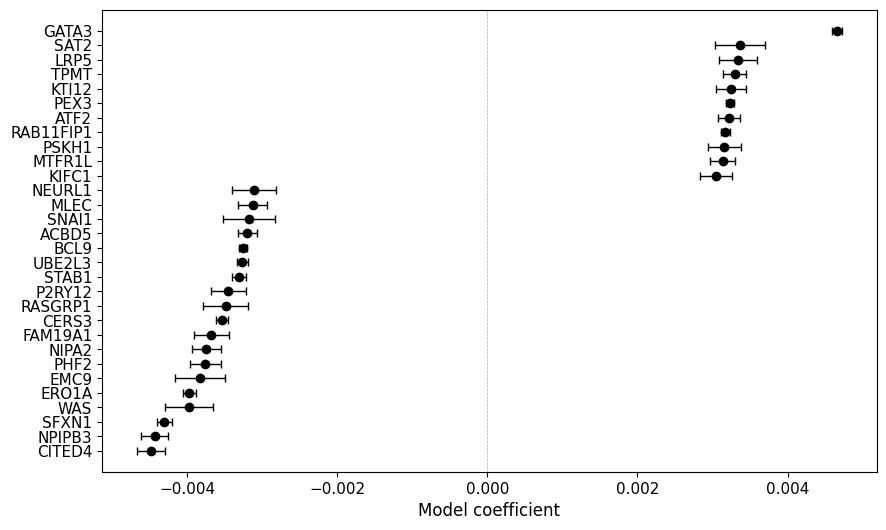

In [116]:
model.plot_coefs(top_n=30, bottom_n=30)

In [84]:
# Compare predictions with different column subsets
n_samples = 10  # Number of different column samples to try
sample_size = 500  # Number of columns to sample each time

predictions = []
for i in range(n_samples):
    # Sample columns
    sampled_cols = np.random.choice(X_perturbs.columns, size=sample_size, replace=False)
    X_sampled = X_perturbs[sampled_cols]

    # Fit model on sampled columns
    model = Perturb2StateModel(pca_transform=True, n_splits=1, n_repeats=1)
    model.fit(X_sampled, y_target, model_id=f"sample_{i}")

    # Get coefficient
    pred = model.get_coefs()
    predictions.append(pred["coef_mean"])

# Stack predictions into DataFrame
all_predictions = pd.concat(predictions, axis=1, keys=[f"sample_{i}" for i in range(n_samples)])

In [93]:
means = all_predictions.mean(1)
sems = all_predictions.sem(1)
df = pd.DataFrame({"mean": means, "sem": sems}).sort_values("mean", ascending=False)
df

,mean,sem
SLC25A13,0.021512,0.002712
RNF41,0.021356,0.000816
ITPKB,0.019447,0.001961
ZNF608,0.018929,0.001734
TMEM107,0.018449,0.001517
...,...,...
PEX11B,-0.020678,0.001424
HINT2,-0.021599,0.003673
PLEKHF2,-0.022103,0.000485
TLX1,-0.022328,0.001583


In [95]:
all_predictions.loc["RNF41"]

sample_0         NaN
sample_1    0.023570
sample_2    0.021433
sample_3         NaN
sample_4         NaN
sample_5         NaN
sample_6    0.023126
sample_7    0.021977
sample_8    0.018466
sample_9    0.019566
Name: RNF41, dtype: float64

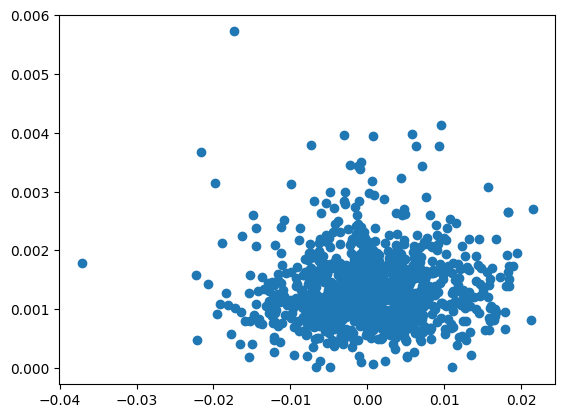

In [92]:
plt.scatter(df["mean"], df["sem"])